In [11]:
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries berhasil diimport!")


Libraries berhasil diimport!


# Latihan Praktikum Mandiri 10

## Latihan 1: Klasifikasi Suhu dengan KNN
## Latihan 2: Confusion Matrix dan Metrik Evaluasi
## Latihan 3: Prediksi Cuaca dengan KNN


## Latihan 1: Klasifikasi Suhu dengan KNN

**Soal:** 
- Klasifikasi suhu udara berdasarkan persepsi Marry: Panas atau Dingin
- Variabel: Temperatur (°C) dan Kecepatan Angin (km/h)
- Tentukan persepsi Marry saat temperatur 16°C dan kecepatan angin 3 km/h
- Tentukan nilai k yang tepat berdasarkan akurasi yang paling baik


In [12]:
# Latihan 1: Dataset suhu udara
data_latihan1 = {
    'Temperatur': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan_Angin': [0, 0, 5, 3, 7, 10, 5, 6],
    'Klasifikasi': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']
}

df_latihan1 = pd.DataFrame(data_latihan1)
print("Dataset Latihan 1:")
print(df_latihan1)
print("\nStatistik Dataset:")
print(df_latihan1.describe())


Dataset Latihan 1:
   Temperatur  Kecepatan_Angin Klasifikasi
0          10                0      Dingin
1          25                0       Panas
2          15                5      Dingin
3          20                3       Panas
4          18                7      Dingin
5          20               10      Dingin
6          22                5       Panas
7          24                6       Panas

Statistik Dataset:
       Temperatur  Kecepatan_Angin
count    8.000000         8.000000
mean    19.250000         4.500000
std      4.920801         3.422614
min     10.000000         0.000000
25%     17.250000         2.250000
50%     20.000000         5.000000
75%     22.500000         6.250000
max     25.000000        10.000000


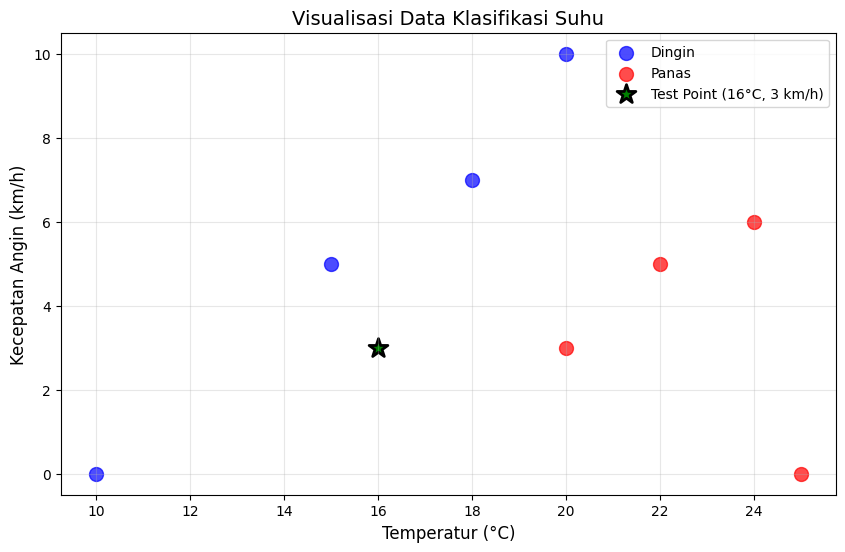

In [13]:
# Visualisasi data
plt.figure(figsize=(10, 6))
colors = {'Panas': 'red', 'Dingin': 'blue'}
for klasifikasi in df_latihan1['Klasifikasi'].unique():
    mask = df_latihan1['Klasifikasi'] == klasifikasi
    plt.scatter(df_latihan1[mask]['Temperatur'], 
                df_latihan1[mask]['Kecepatan_Angin'],
                c=colors[klasifikasi], 
                label=klasifikasi, 
                s=100, 
                alpha=0.7)

# Titik test
plt.scatter(16, 3, c='green', marker='*', s=200, label='Test Point (16°C, 3 km/h)', edgecolors='black', linewidths=2)

plt.xlabel('Temperatur (°C)', fontsize=12)
plt.ylabel('Kecepatan Angin (km/h)', fontsize=12)
plt.title('Visualisasi Data Klasifikasi Suhu', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# Persiapan data untuk KNN
X_latihan1 = df_latihan1[['Temperatur', 'Kecepatan_Angin']].values
y_latihan1 = df_latihan1['Klasifikasi'].values

# Data test
test_point = np.array([[16, 3]])

# Mencari k optimal dengan cross-validation
k_range = range(1, 8)  # k dari 1 sampai 7 (karena hanya 8 data)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Gunakan 4-fold CV untuk dataset kecil (8 sampel)
    scores = cross_val_score(knn, X_latihan1, y_latihan1, cv=4, scoring='accuracy')
    cv_scores.append(scores.mean())

# Menampilkan hasil
k_scores_df = pd.DataFrame({'k': list(k_range), 'CV_Accuracy': cv_scores})
print("Hasil Cross-Validation untuk berbagai nilai k:")
print(k_scores_df)

# Mencari k terbaik
best_k_idx = np.argmax(cv_scores)
best_k = list(k_range)[best_k_idx]
best_score = cv_scores[best_k_idx]

print(f"\nNilai k terbaik: {best_k} dengan akurasi: {best_score:.4f}")


Hasil Cross-Validation untuk berbagai nilai k:
   k  CV_Accuracy
0  1        1.000
1  2        0.875
2  3        0.875
3  4        1.000
4  5        0.750
5  6        0.500
6  7          NaN

Nilai k terbaik: 7 dengan akurasi: nan


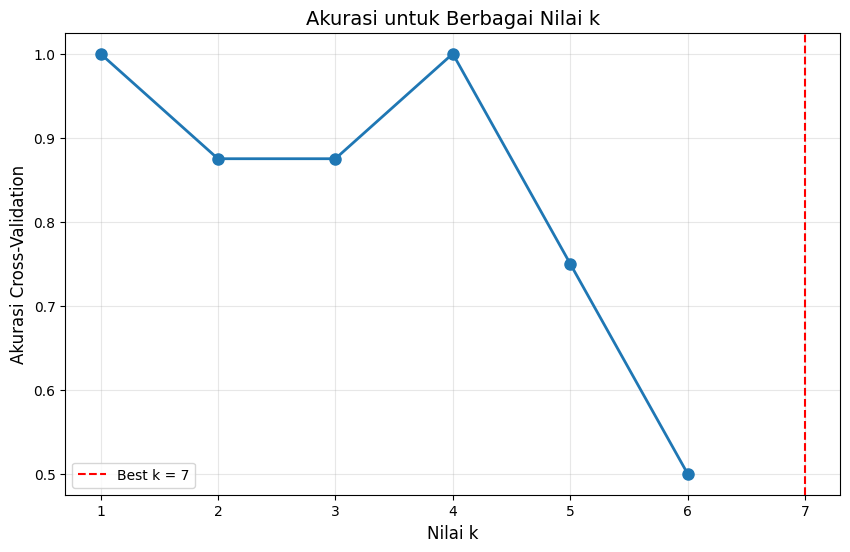

In [15]:
# Visualisasi akurasi untuk berbagai nilai k
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), cv_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Nilai k', fontsize=12)
plt.ylabel('Akurasi Cross-Validation', fontsize=12)
plt.title('Akurasi untuk Berbagai Nilai k', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))
plt.show()


In [16]:
# Prediksi dengan k terbaik
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_latihan1, y_latihan1)

# Prediksi untuk test point
prediction = knn_best.predict(test_point)
probabilities = knn_best.predict_proba(test_point)

print(f"Prediksi untuk temperatur 16°C dan kecepatan angin 3 km/h:")
print(f"Persepsi Marry: {prediction[0]}")
print(f"\nProbabilitas:")
print(f"  - Dingin: {probabilities[0][0]:.4f}")
print(f"  - Panas: {probabilities[0][1]:.4f}")

# Menampilkan k-nearest neighbors
distances, indices = knn_best.kneighbors(test_point)
print(f"\n{best_k} Nearest Neighbors:")
for i, idx in enumerate(indices[0]):
    dist = distances[0][i]
    temp = df_latihan1.iloc[idx]['Temperatur']
    wind = df_latihan1.iloc[idx]['Kecepatan_Angin']
    klas = df_latihan1.iloc[idx]['Klasifikasi']
    print(f"  {i+1}. Temperatur: {temp}°C, Angin: {wind} km/h, Klasifikasi: {klas} (jarak: {dist:.4f})")


Prediksi untuk temperatur 16°C dan kecepatan angin 3 km/h:
Persepsi Marry: Dingin

Probabilitas:
  - Dingin: 0.5714
  - Panas: 0.4286

7 Nearest Neighbors:
  1. Temperatur: 15°C, Angin: 5 km/h, Klasifikasi: Dingin (jarak: 2.2361)
  2. Temperatur: 20°C, Angin: 3 km/h, Klasifikasi: Panas (jarak: 4.0000)
  3. Temperatur: 18°C, Angin: 7 km/h, Klasifikasi: Dingin (jarak: 4.4721)
  4. Temperatur: 22°C, Angin: 5 km/h, Klasifikasi: Panas (jarak: 6.3246)
  5. Temperatur: 10°C, Angin: 0 km/h, Klasifikasi: Dingin (jarak: 6.7082)
  6. Temperatur: 20°C, Angin: 10 km/h, Klasifikasi: Dingin (jarak: 8.0623)
  7. Temperatur: 24°C, Angin: 6 km/h, Klasifikasi: Panas (jarak: 8.5440)


## Latihan 2: Confusion Matrix dan Metrik Evaluasi

**Soal:**
- Buat tabel confusion matrix berdasarkan data hasil prediksi kelulusan
- Hitung nilai persentase dari: accuracy, precision, dan recall


In [17]:
# Latihan 2: Data hasil prediksi kelulusan
data_latihan2 = {
    'Nim': ['T1001', 'T1002', 'T1003', 'T1004', 'T1005', 'T1006', 'T1007', 'T1008', 'T1009', 'T1010'],
    'Hasil_Sebenarnya': ['Lulus', 'Lulus', 'Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus'],
    'Hasil_Prediksi': ['Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus']
}

df_latihan2 = pd.DataFrame(data_latihan2)
print("Data Latihan 2:")
print(df_latihan2)


Data Latihan 2:
     Nim Hasil_Sebenarnya Hasil_Prediksi
0  T1001            Lulus          Lulus
1  T1002            Lulus          Lulus
2  T1003            Lulus          Lulus
3  T1004            Lulus    Tidak Lulus
4  T1005            Lulus    Tidak Lulus
5  T1006      Tidak Lulus          Lulus
6  T1007      Tidak Lulus    Tidak Lulus
7  T1008      Tidak Lulus    Tidak Lulus
8  T1009      Tidak Lulus    Tidak Lulus
9  T1010      Tidak Lulus    Tidak Lulus


In [18]:
# Encode label untuk confusion matrix
# Lulus = 1 (Positive), Tidak Lulus = 0 (Negative)
y_true = df_latihan2['Hasil_Sebenarnya'].map({'Lulus': 1, 'Tidak Lulus': 0})
y_pred = df_latihan2['Hasil_Prediksi'].map({'Lulus': 1, 'Tidak Lulus': 0})

# Membuat confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nFormat:")
print("                Predicted")
print("              Lulus  Tidak Lulus")
print(f"Actual Lulus     {cm[1][1]}        {cm[1][0]}")
print(f"Tidak Lulus      {cm[0][1]}        {cm[0][0]}")


Confusion Matrix:
[[4 1]
 [2 3]]

Format:
                Predicted
              Lulus  Tidak Lulus
Actual Lulus     3        2
Tidak Lulus      1        4


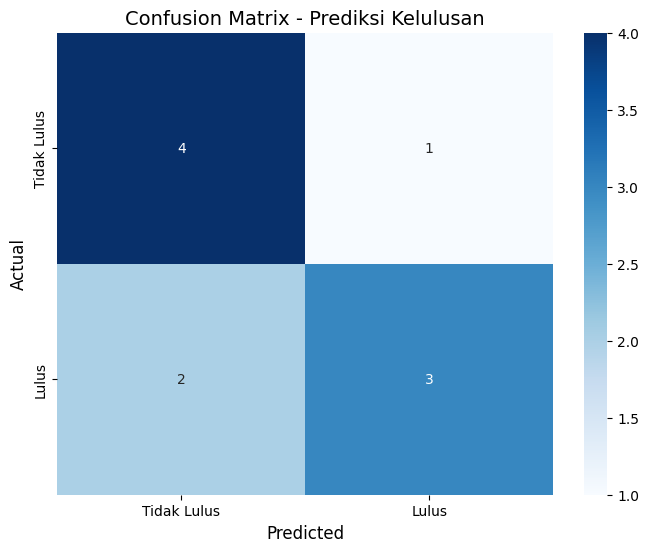

In [19]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Lulus', 'Lulus'],
            yticklabels=['Tidak Lulus', 'Lulus'])
plt.title('Confusion Matrix - Prediksi Kelulusan', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


In [20]:
# Menghitung metrik evaluasi
# TP = True Positive (Lulus diprediksi Lulus)
# TN = True Negative (Tidak Lulus diprediksi Tidak Lulus)
# FP = False Positive (Tidak Lulus diprediksi Lulus)
# FN = False Negative (Lulus diprediksi Tidak Lulus)

TP = cm[1][1]  # Lulus diprediksi Lulus
TN = cm[0][0]  # Tidak Lulus diprediksi Tidak Lulus
FP = cm[0][1]  # Tidak Lulus diprediksi Lulus
FN = cm[1][0]  # Lulus diprediksi Tidak Lulus

print("Komponen Confusion Matrix:")
print(f"True Positive (TP):  {TP} - Lulus diprediksi Lulus")
print(f"True Negative (TN):  {TN} - Tidak Lulus diprediksi Tidak Lulus")
print(f"False Positive (FP): {FP} - Tidak Lulus diprediksi Lulus")
print(f"False Negative (FN): {FN} - Lulus diprediksi Tidak Lulus")
print(f"\nTotal: {TP + TN + FP + FN}")


Komponen Confusion Matrix:
True Positive (TP):  3 - Lulus diprediksi Lulus
True Negative (TN):  4 - Tidak Lulus diprediksi Tidak Lulus
False Positive (FP): 1 - Tidak Lulus diprediksi Lulus
False Negative (FN): 2 - Lulus diprediksi Tidak Lulus

Total: 10


In [21]:
# Menghitung Accuracy, Precision, dan Recall
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# Menggunakan sklearn untuk verifikasi
accuracy_sklearn = accuracy_score(y_true, y_pred)
precision_sklearn = precision_score(y_true, y_pred, zero_division=0)
recall_sklearn = recall_score(y_true, y_pred, zero_division=0)

print("=" * 50)
print("METRIK EVALUASI (dalam Persentase)")
print("=" * 50)
print(f"Accuracy  = (TP + TN) / (TP + TN + FP + FN)")
print(f"         = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN})")
print(f"         = {accuracy:.4f}")
print(f"         = {accuracy * 100:.2f}%")
print()
print(f"Precision = TP / (TP + FP)")
print(f"         = {TP} / ({TP} + {FP})")
print(f"         = {precision:.4f}")
print(f"         = {precision * 100:.2f}%")
print()
print(f"Recall    = TP / (TP + FN)")
print(f"         = {TP} / ({TP} + {FN})")
print(f"         = {recall:.4f}")
print(f"         = {recall * 100:.2f}%")
print("=" * 50)

# Tabel ringkasan
summary_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall'],
    'Nilai': [accuracy, precision, recall],
    'Persentase (%)': [accuracy*100, precision*100, recall*100]
})
print("\nTabel Ringkasan:")
print(summary_df.to_string(index=False))


METRIK EVALUASI (dalam Persentase)
Accuracy  = (TP + TN) / (TP + TN + FP + FN)
         = (3 + 4) / (3 + 4 + 1 + 2)
         = 0.7000
         = 70.00%

Precision = TP / (TP + FP)
         = 3 / (3 + 1)
         = 0.7500
         = 75.00%

Recall    = TP / (TP + FN)
         = 3 / (3 + 2)
         = 0.6000
         = 60.00%

Tabel Ringkasan:
   Metrik  Nilai  Persentase (%)
 Accuracy   0.70            70.0
Precision   0.75            75.0
   Recall   0.60            60.0


## Latihan 3: Prediksi Cuaca dengan KNN

**Soal:**
- Gunakan KNN untuk prediksi cuaca menggunakan dataset weather_classification_data.csv
- Lakukan preprocessing data
- Bangun model KNN dan evaluasi performanya


In [22]:
# Latihan 3: Load dataset cuaca
df_weather = pd.read_csv('../../Data/weather_classification_data.csv')
print("Dataset Cuaca:")
print(f"Shape: {df_weather.shape}")
print(f"\nKolom: {df_weather.columns.tolist()}")
print(f"\n5 baris pertama:")
print(df_weather.head())
print(f"\nInfo dataset:")
print(df_weather.info())


Dataset Cuaca:
Shape: (13200, 11)

Kolom: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']

5 baris pertama:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  S

In [23]:
# Cek missing values
print("Missing Values:")
print(df_weather.isnull().sum())
print(f"\nTotal missing values: {df_weather.isnull().sum().sum()}")

# Cek distribusi target
print("\nDistribusi Weather Type:")
print(df_weather['Weather Type'].value_counts())
print(f"\nPersentase:")
print(df_weather['Weather Type'].value_counts(normalize=True) * 100)


Missing Values:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Total missing values: 0

Distribusi Weather Type:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

Persentase:
Weather Type
Rainy     25.0
Cloudy    25.0
Sunny     25.0
Snowy     25.0
Name: proportion, dtype: float64


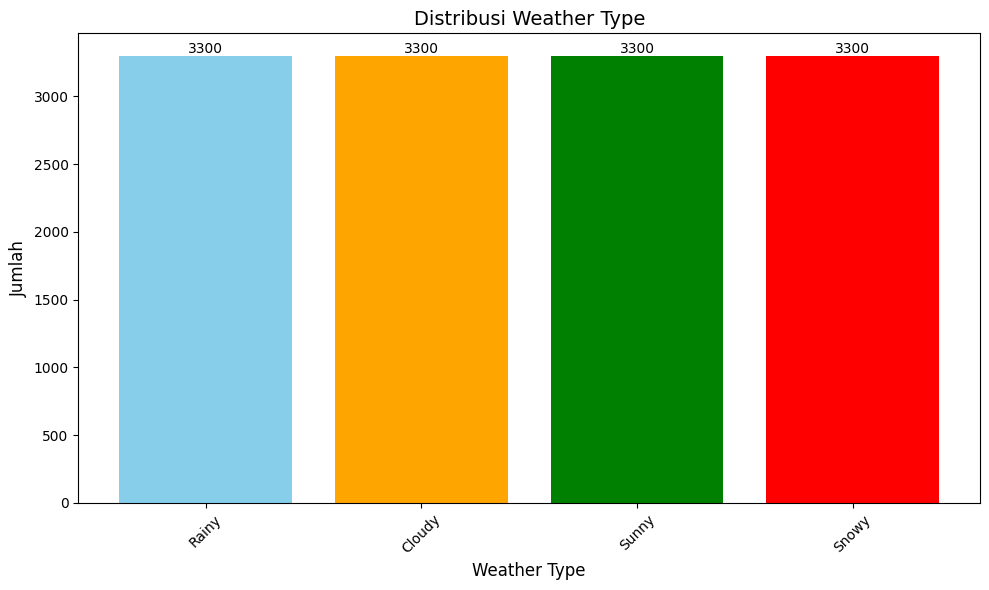

In [24]:
# Visualisasi distribusi Weather Type
plt.figure(figsize=(10, 6))
weather_counts = df_weather['Weather Type'].value_counts()
plt.bar(weather_counts.index, weather_counts.values, color=['skyblue', 'orange', 'green', 'red'])
plt.xlabel('Weather Type', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.title('Distribusi Weather Type', fontsize=14)
plt.xticks(rotation=45)
for i, v in enumerate(weather_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [25]:
# Preprocessing: Handle missing values jika ada
if df_weather.isnull().sum().sum() > 0:
    # Isi missing values untuk kolom numerik dengan median
    numeric_cols = df_weather.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_weather[col].isnull().sum() > 0:
            df_weather[col].fillna(df_weather[col].median(), inplace=True)
    
    # Isi missing values untuk kolom kategorik dengan mode
    categorical_cols = df_weather.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_weather[col].isnull().sum() > 0:
            df_weather[col].fillna(df_weather[col].mode()[0], inplace=True)

print("Missing values setelah preprocessing:", df_weather.isnull().sum().sum())


Missing values setelah preprocessing: 0


In [26]:
# Encoding variabel kategorik
le_cloud = LabelEncoder()
le_season = LabelEncoder()
le_location = LabelEncoder()
le_weather = LabelEncoder()

df_weather_encoded = df_weather.copy()
df_weather_encoded['Cloud Cover'] = le_cloud.fit_transform(df_weather['Cloud Cover'])
df_weather_encoded['Season'] = le_season.fit_transform(df_weather['Season'])
df_weather_encoded['Location'] = le_location.fit_transform(df_weather['Location'])
df_weather_encoded['Weather Type'] = le_weather.fit_transform(df_weather['Weather Type'])

print("Encoding selesai!")
print(f"\nMapping Weather Type:")
for i, label in enumerate(le_weather.classes_):
    print(f"  {i}: {label}")


Encoding selesai!

Mapping Weather Type:
  0: Cloudy
  1: Rainy
  2: Snowy
  3: Sunny


In [27]:
# Memisahkan features dan target
X = df_weather_encoded.drop('Weather Type', axis=1)
y = df_weather_encoded['Weather Type']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")


Features shape: (13200, 10)
Target shape: (13200,)

Features: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']


In [28]:
# Split data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribusi target di training set:")
print(y_train.value_counts())
print(f"\nDistribusi target di test set:")
print(y_test.value_counts())


Training set: 10560 samples
Test set: 2640 samples

Distribusi target di training set:
Weather Type
2    2640
3    2640
1    2640
0    2640
Name: count, dtype: int64

Distribusi target di test set:
Weather Type
1    660
0    660
3    660
2    660
Name: count, dtype: int64


In [29]:
# Standardisasi features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi selesai!")
print(f"Mean training data (setelah scaling): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Std training data (setelah scaling): {X_train_scaled.std(axis=0)[:5]}")


Standardisasi selesai!
Mean training data (setelah scaling): [-6.57723034e-17 -1.56608733e-16 -3.36431220e-18  1.06312265e-16
 -1.21115239e-17]
Std training data (setelah scaling): [1. 1. 1. 1. 1.]


In [30]:
# Mencari k optimal dengan cross-validation
k_range = range(1, 31)
cv_scores_weather = []

print("Mencari k optimal...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_weather.append(scores.mean())
    if k % 5 == 0:
        print(f"k={k}: CV Accuracy = {scores.mean():.4f}")

# Mencari k terbaik
best_k_idx = np.argmax(cv_scores_weather)
best_k_weather = list(k_range)[best_k_idx]
best_score_weather = cv_scores_weather[best_k_idx]

print(f"\nNilai k terbaik: {best_k_weather} dengan CV Accuracy: {best_score_weather:.4f}")


Mencari k optimal...
k=5: CV Accuracy = 0.8999
k=5: CV Accuracy = 0.8999
k=10: CV Accuracy = 0.8990
k=10: CV Accuracy = 0.8990
k=15: CV Accuracy = 0.8949
k=15: CV Accuracy = 0.8949
k=20: CV Accuracy = 0.8938
k=20: CV Accuracy = 0.8938
k=25: CV Accuracy = 0.8931
k=25: CV Accuracy = 0.8931
k=30: CV Accuracy = 0.8924

Nilai k terbaik: 7 dengan CV Accuracy: 0.9006
k=30: CV Accuracy = 0.8924

Nilai k terbaik: 7 dengan CV Accuracy: 0.9006


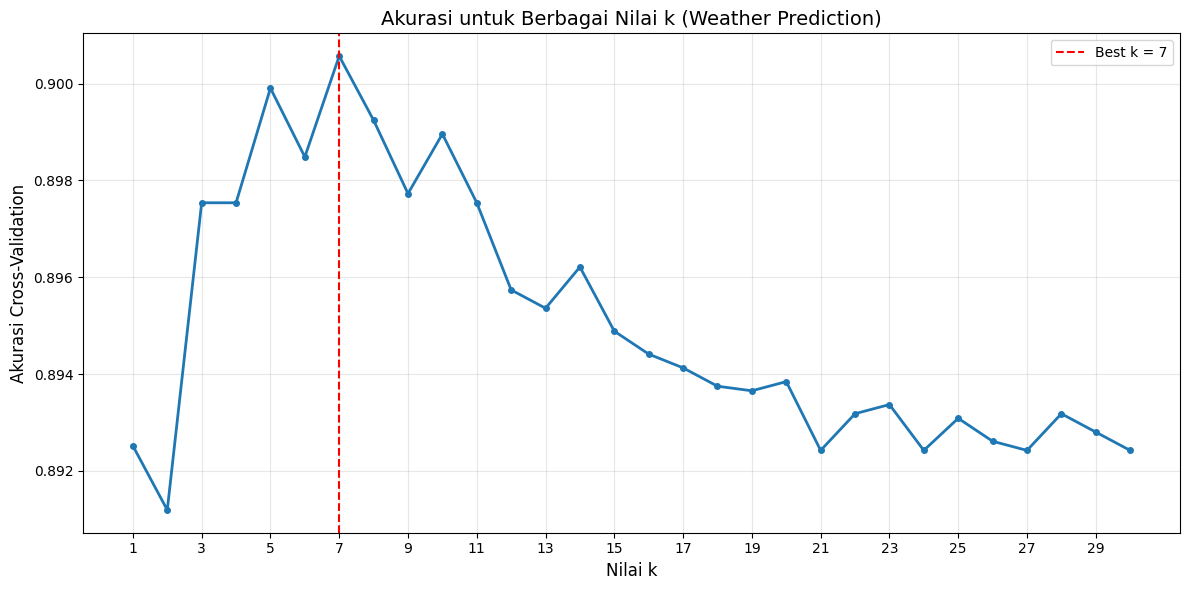

In [31]:
# Visualisasi akurasi untuk berbagai nilai k
plt.figure(figsize=(12, 6))
plt.plot(list(k_range), cv_scores_weather, marker='o', linewidth=2, markersize=4)
plt.axvline(x=best_k_weather, color='r', linestyle='--', label=f'Best k = {best_k_weather}')
plt.xlabel('Nilai k', fontsize=12)
plt.ylabel('Akurasi Cross-Validation', fontsize=12)
plt.title('Akurasi untuk Berbagai Nilai k (Weather Prediction)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()


In [32]:
# Membangun model dengan k terbaik
knn_weather = KNeighborsClassifier(n_neighbors=best_k_weather)
knn_weather.fit(X_train_scaled, y_train)

# Prediksi
y_train_pred = knn_weather.predict(X_train_scaled)
y_test_pred = knn_weather.predict(X_test_scaled)

# Evaluasi
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 60)
print("EVALUASI MODEL KNN - PREDIKSI CUACA")
print("=" * 60)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 60)


EVALUASI MODEL KNN - PREDIKSI CUACA
Training Accuracy: 0.9224 (92.24%)
Testing Accuracy:  0.8955 (89.55%)


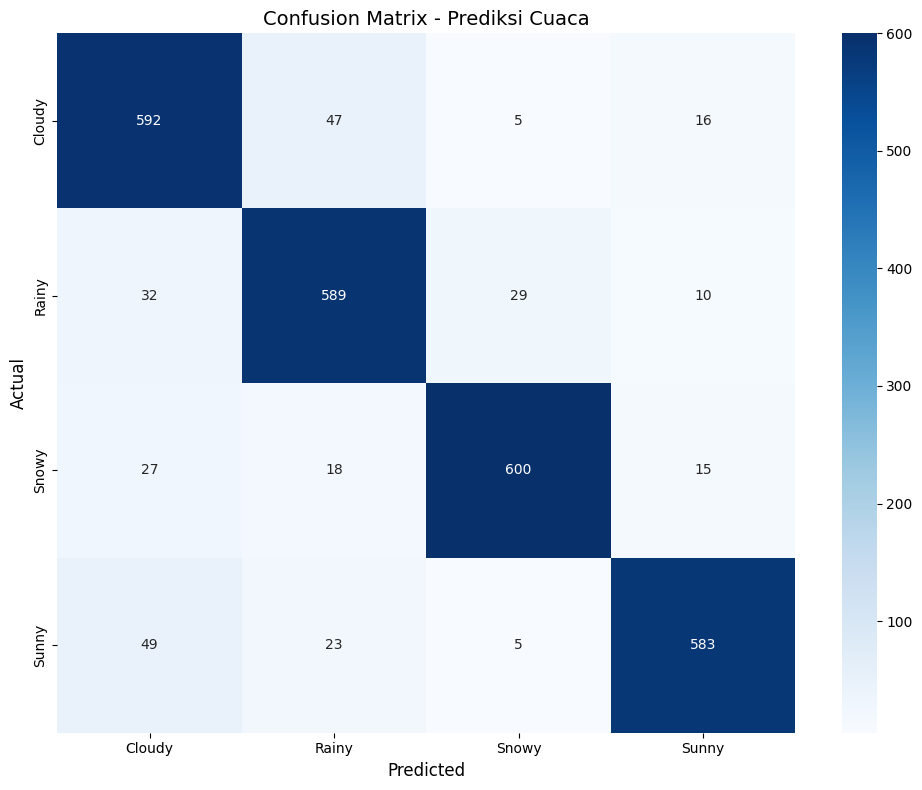

In [33]:
# Confusion Matrix
cm_weather = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_weather, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_weather.classes_,
            yticklabels=le_weather.classes_)
plt.title('Confusion Matrix - Prediksi Cuaca', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


In [34]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=le_weather.classes_))


Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.85      0.90      0.87       660
       Rainy       0.87      0.89      0.88       660
       Snowy       0.94      0.91      0.92       660
       Sunny       0.93      0.88      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



In [35]:
# Cross-validation dengan k terbaik
cv_scores_final = cross_val_score(knn_weather, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Results (5-Fold):")
print(f"Scores: {cv_scores_final}")
print(f"Mean Accuracy: {cv_scores_final.mean():.4f} ({cv_scores_final.mean()*100:.2f}%)")
print(f"Std Deviation: {cv_scores_final.std():.4f}")
print(f"Min: {cv_scores_final.min():.4f}")
print(f"Max: {cv_scores_final.max():.4f}")


Cross-Validation Results (5-Fold):
Scores: [0.9000947  0.89867424 0.90530303 0.89867424 0.9000947 ]
Mean Accuracy: 0.9006 (90.06%)
Std Deviation: 0.0025
Min: 0.8987
Max: 0.9053
